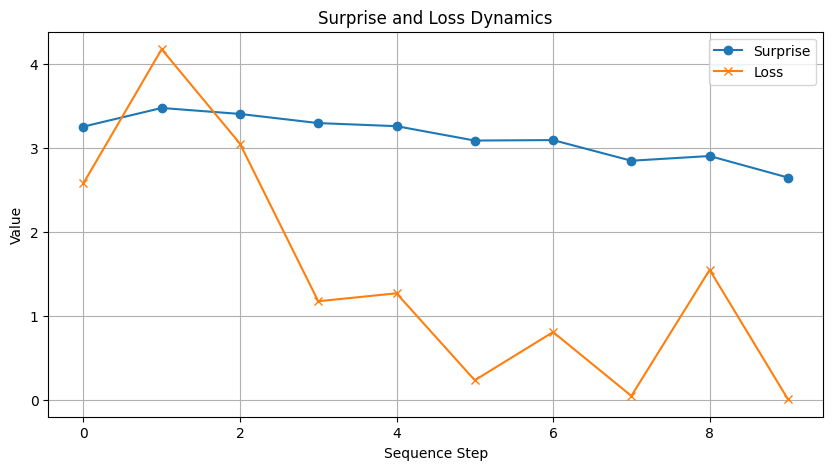

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Sample input data (e.g., 10 tokens, 1 feature)
input_seq = torch.randn(10, 1)

class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
    def forward(self, x):
        return self.linear(x)

# Instantiate the model and optimizer
model = SimpleModel()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Lists to track the surprise and loss for visualization
surprise_values = []
loss_values = []

# Simplified surprise mechanism with decay
surprise_decay = 0.9  # How fast surprise decays over time
for i in range(len(input_seq)):
    input_token = input_seq[i]
    input_token.requires_grad = True  # Track gradient for input

    # Make a prediction
    output = model(input_token)

    # Sample Loss
    loss = (output - input_token) ** 2  # Example loss

    # Backpropagate to calculate gradients
    optimizer.zero_grad()
    loss.backward()

    # Calculate and decay surprise
    surprise = torch.abs(input_token.grad).item()
    if i > 0:
        surprise = surprise_decay * surprise_values[-1] + (1 - surprise_decay) * surprise

    # Track loss and surprise
    surprise_values.append(surprise)
    loss_values.append(loss.item())

    # Update model weights based on "surprise" (gradient magnitude)
    with torch.no_grad():
        model.linear.weight -= 0.1 * input_token.grad

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(surprise_values, label='Surprise', marker='o')
plt.plot(loss_values, label='Loss', marker='x')
plt.xlabel('Sequence Step')
plt.ylabel('Value')
plt.title('Surprise and Loss Dynamics')
plt.legend()
plt.grid()
plt.show()

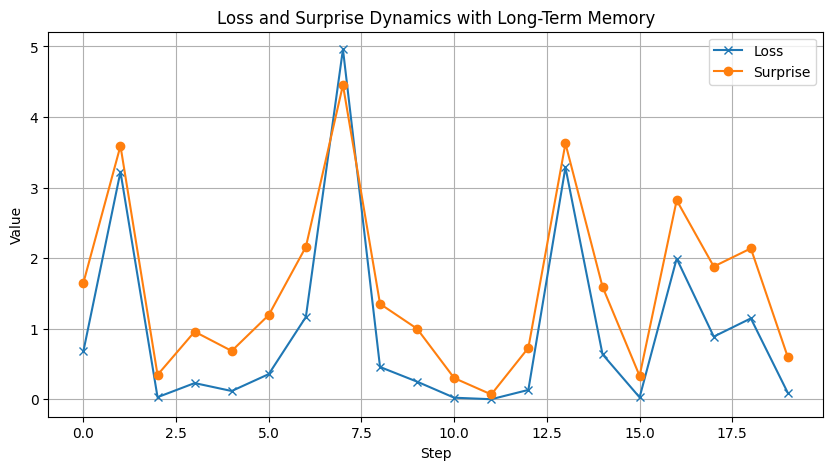

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Example Input Sequence
input_seq = torch.randn(20, 1)  # Sequence of 20 tokens, each with 1 feature

class LongTermMemory(nn.Module):
    def __init__(self, memory_size=10, feature_size=1):
        super().__init__()
        self.memory = nn.Parameter(torch.zeros(memory_size, feature_size))
        self.memory_size = memory_size
        self.feature_size = feature_size
        self.W_query = nn.Linear(feature_size, feature_size)
        self.W_key = nn.Linear(feature_size, feature_size)
        self.W_value = nn.Linear(feature_size, feature_size)

    def forward(self, x):
        # Compute keys, queries, and values
        query = self.W_query(x)
        keys = self.W_key(self.memory)
        values = self.W_value(self.memory)

        # Compute attention weights for memory retrieval
        attention_scores = torch.softmax(torch.matmul(query, keys.T), dim=-1)
        retrieved_memory = torch.matmul(attention_scores, values)
        return retrieved_memory, attention_scores

    def update_memory(self, x, surprise, forget_rate=0.1):
        # Forget a fraction of memory based on forget rate
        self.memory.data *= (1 - forget_rate)

        # Add the new input, weighted by its surprise
        with torch.no_grad():
            # Directly use the surprise as a scalar without torch.abs
            insertion_index = int(surprise) % self.memory_size
            self.memory.data[insertion_index] = x


# Simplified model integrating the memory module
class TitansModel(nn.Module):
    def __init__(self, memory_size=10, feature_size=1):
        super().__init__()
        self.memory_module = LongTermMemory(memory_size, feature_size)
        self.output_layer = nn.Linear(feature_size, 1)

    def forward(self, x):
        retrieved_memory, attention_scores = self.memory_module(x)
        output = self.output_layer(retrieved_memory)
        return output, attention_scores

# Initialize model and optimizer
model = TitansModel(memory_size=5, feature_size=1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Lists for tracking dynamics
losses = []
surprise_values = []

# Training loop with surprise-based memory update
for i, input_token in enumerate(input_seq):
    input_token.requires_grad = True

    # Forward pass
    output, attention_scores = model(input_token)
    loss = (output - input_token) ** 2  # Example squared loss

    # Backpropagation to compute gradients
    optimizer.zero_grad()
    loss.backward()

    # Calculate the "surprise" as the gradient of loss with respect to input
    surprise = torch.abs(input_token.grad).item()
    surprise_values.append(surprise)

    # Update memory with surprise
    model.memory_module.update_memory(input_token.detach(), surprise)

    # Optimize model parameters
    optimizer.step()

    # Track loss
    losses.append(loss.item())

# Visualization of loss and surprise dynamics
plt.figure(figsize=(10, 5))
plt.plot(losses, label="Loss", marker="x")
plt.plot(surprise_values, label="Surprise", marker="o")
plt.title("Loss and Surprise Dynamics with Long-Term Memory")
plt.xlabel("Step")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()

In [ ]:
import torch
import torch.nn as nn

# Define a simple long-term memory module inspired by Titans
class LongTermMemory(nn.Module):
    def __init__(self, input_size, memory_size):
        super().__init__()
        self.memory = nn.Parameter(torch.zeros(memory_size, input_size))
        self.W_query = nn.Linear(input_size, input_size)
        self.W_key = nn.Linear(input_size, input_size)
        self.W_value = nn.Linear(input_size, input_size)

    def forward(self, x):
        query = self.W_query(x)
        keys = self.W_key(self.memory)
        values = self.W_value(self.memory)

        # Attention to retrieve relevant memory
        attention_scores = torch.softmax(torch.matmul(query, keys.T), dim=-1)
        retrieved_memory = torch.matmul(attention_scores, values)
        return retrieved_memory, attention_scores

    def update_memory(self, x, surprise, decay=0.9):
        # Memory forgetting mechanism
        self.memory.data *= decay

        # Update memory with new data based on surprise
        with torch.no_grad():
            update_index = surprise.argmax().item() % self.memory.size(0)
            self.memory.data[update_index] = x

# Simple test model incorporating memory
class TestModel(nn.Module):
    def __init__(self, input_size, memory_size):
        super().__init__()
        self.memory = LongTermMemory(input_size, memory_size)
        self.output_layer = nn.Linear(input_size, 1)

    def forward(self, x):
        retrieved_memory, _ = self.memory(x)
        output = self.output_layer(retrieved_memory)
        return output

    def test_update(self, x, target, loss_fn):
        # Ensure x is a leaf tensor
        x = x.detach().clone().requires_grad_(True)

        # Perform forward pass
        output = self(x)
        loss = loss_fn(output, target)

        # Calculate surprise as gradient magnitude
        loss.backward()
        surprise = torch.abs(x.grad)  # Gradient will now be populated

        # Update memory based on surprise
        self.memory.update_memory(x.detach(), surprise)

        return loss.item()

# Define the model, loss, and sample data
input_size = 4
memory_size = 5
model = TestModel(input_size, memory_size)
loss_fn = nn.MSELoss()

# Test sequence
test_data = torch.randn(10, input_size, requires_grad=True)
targets = torch.randn(10, 1)

# Test-time updates
for i in range(len(test_data)):
    input_token = test_data[i:i+1]
    target = targets[i:i+1]

    loss = model.test_update(input_token, target, loss_fn)
    print(f"Step {i+1}, Loss: {loss:.4f}")

Step 1, Loss: 0.4449
Step 2, Loss: 1.5072
Step 3, Loss: 1.5884
Step 4, Loss: 1.4903
Step 5, Loss: 0.5120
Step 6, Loss: 4.0555
Step 7, Loss: 2.4942
Step 8, Loss: 0.1973
Step 9, Loss: 0.2861
Step 10, Loss: 0.0441
